In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    cv2 = None

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['image.cmap'] = 'gray'


In [2]:
def show_image(img, title='', cmap='gray'):
    plt.figure(figsize=(5, 5))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()


def show_images(images, titles=None, cols=3, cmap='gray', figsize=(14, 8)):
    n = len(images)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)
        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


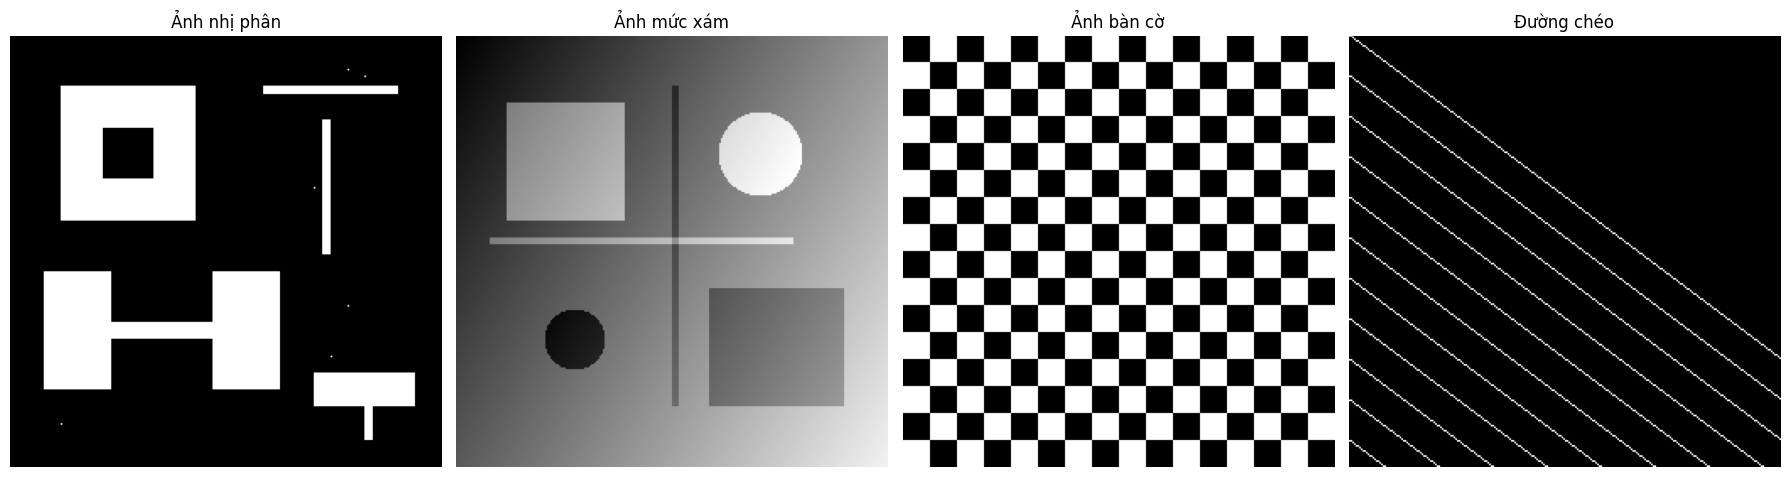

In [4]:
def make_binary_test_image(size=256):
    img = np.zeros((size, size), dtype=np.uint8)
    img[30:110, 30:110] = 255
    img[55:85, 55:85] = 0
    img[140:210, 20:60] = 255
    img[170:180, 60:120] = 255
    img[140:210, 120:160] = 255
    img[30:35, 150:230] = 255
    img[50:130, 185:190] = 255
    img[200:220, 180:240] = 255
    img[220:240, 210:215] = 255
    noise_points = [(20, 200), (24, 210), (90, 180), (160, 200), (190, 190), (230, 30)]
    for r, c in noise_points:
        img[r, c] = 255
    return img


def make_grayscale_test_image(size=256):
    y, x = np.mgrid[0:size, 0:size]
    base = 40 + 0.5 * x + 0.3 * y
    img = base.astype(np.float32)
    img[40:110, 30:100] += 80
    img[150:220, 150:230] -= 50
    rr = (x - 180) ** 2 + (y - 70) ** 2
    img[rr < 25**2] += 90
    img[(x - 70) ** 2 + (y - 180) ** 2 < 18**2] -= 70
    img[120:124, 20:200] += 60
    img[30:220, 128:132] -= 40
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)


def make_checkerboard(size=256, block=16):
    y, x = np.indices((size, size))
    board = ((x // block + y // block) % 2) * 255
    return board.astype(np.uint8)


def make_diagonal_lines(size=256):
    """Ảnh với nhiều đường chéo mảnh -- đặc biệt nhạy cảm với răng cưa."""
    img = np.zeros((size, size), dtype=np.uint8)
    for k in range(0, size, 24):
        for t in range(size):
            r = k + t * 3 // 4
            c = t
            if 0 <= r < size:
                img[r, c] = 255
    return img


binary_img = make_binary_test_image()
grayscale_img = make_grayscale_test_image()
checkerboard_img = make_checkerboard()
diagonal_img = make_diagonal_lines()

show_images(
    [binary_img, grayscale_img, checkerboard_img, diagonal_img],
    titles=['Ảnh nhị phân', 'Ảnh mức xám', 'Ảnh bàn cờ', 'Đường chéo'],
    cols=4,
    figsize=(18, 5)
)


In [5]:
# TODO: Sinh viên tự viết hàm padding cho ảnh nhị phân

def pad_binary_image_manual(img, pad_h, pad_w, mode='constant'):
    # Yêu cầu tối thiểu:
    # - Hỗ trợ mode='constant'
    # - Có thể mở rộng thêm mode khác nếu muốn
    if mode != 'constant':
        return NotImplementedError
    w, h = img.shape
    padded = np.zeros((w + 2 * pad_h, h + 2 * pad_w), dtype=img.dtype)
    for r in range(w):
        for c in range(h):
            padded[r + pad_h, c + pad_w] = img[r, c]
    return padded

# TODO: Sinh viên tự viết tích chập 2D bằng vòng lặp
# Không được dùng bất kỳ hàm tích chập có sẵn nào.

def convolve2d_manual(img, kernel, pad_mode='constant', pad_value=0):
    """
    Tích chập 2D thủ công -- kernel CỐ ĐỊNH, trượt qua toàn ảnh.

    Dùng cho:
      - SSAA: kernel = np.ones((L,L))/L**2  (box filter)
      - Làm mượt sau warp: kernel = gaussian_kernel(n)
    KHÔNG dùng cho Bicubic/Lanczos (kernel của chúng thay đổi theo delta).

    Tham số
    -------
    img       : np.ndarray (H, W), kiểu float
    kernel    : np.ndarray (kH, kW)  -- cố định, không phụ thuộc vào vị trí
    pad_mode  : 'constant' -- điền pad_value ngoài biên
    pad_value : giá trị điền khi pad_mode='constant'

    Trả về
    ------
    out : np.ndarray (H, W), cùng kiểu với img

    Gợi ý các bước
    --------------
    1. Lật kernel 180° (flip cả hàng lẫn cột) -- đây là điểm khác biệt
       giữa convolution và cross-correlation.
    2. Pad ảnh đầu vào đủ để giữ nguyên kích thước đầu ra.
    3. Duyệt từng pixel (r, c), tính tổng trọng số cửa sổ kernel.
    """
    h, w = img.shape
    kh, kw = kernel.shape
    ph = kh // 2
    pw = kw // 2
    padded = pad_binary_image_manual(img, ph, pw, mode=pad_mode)
    out = np.zeros_like(img)
    flipped_kernel = np.flip(kernel)
    for r in range(h):
        for c in range(w):
            sum_val = 0.0
            for kr in range(kh):
                for kc in range(kw):
                    val = padded[r + kr, c + kc] * flipped_kernel[kr, kc]
                    sum_val += val
            out[r, c] = sum_val
    return out


In [6]:
def sobel_gradients(img):
    """Tính gradient Sobel bằng vòng lặp 2D trực quan."""
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
    Ky = Kx.T
    H, W = img.shape
    padded = np.pad(img, pad_width=1, mode='reflect')
    Ix = np.zeros_like(img)
    Iy = np.zeros_like(img)
    for r in range(H):
        for c in range(W):
            neighbor = padded[r:r+3, c:c+3]
            val_x = 0.0
            val_y = 0.0
            for i in range(3):
                for j in range(3):
                    val_x += neighbor[i, j] * Kx[i, j]
                    val_y += neighbor[i, j] * Ky[i, j]
            Ix[r, c] = val_x
            Iy[r, c] = val_y
    magnitude = np.sqrt(Ix**2 + Iy**2)
    direction = np.arctan2(Iy, Ix)

    return Ix, Iy, magnitude, direction

def gaussian_kernel_2d(sigma):
    """Tạo kernel Gaussian 2D."""
    r = int(3*sigma + 0.5)
    k = 2*r + 1
    ax = np.arange(-r, r+1, dtype=np.float64)
    xx, yy = np.meshgrid(ax, ax)
    kern = np.exp(-(xx**2 + yy**2) / (2*sigma**2))
    return kern / kern.sum()

def gaussian_blur(img, sigma):
    """Blur ảnh bằng Gaussian dùng vòng lặp 2D."""
    kern = gaussian_kernel_2d(sigma)
    k = kern.shape[0]
    r = k // 2
    H, W = img.shape
    padded = np.pad(img, pad_width=r, mode='reflect')
    blurred = np.zeros_like(img)
    for row in range(H):
        for col in range(W):
            neighbor = padded[row:row+k, col:col+k]
            val = 0.0
            for i in range(k):
                for j in range(k):
                    val += neighbor[i, j] * kern[i, j]
            blurred[row, col] = val
    return blurred

def nms_2d(response, window=9, threshold=0.0):
    """Non-Maximum Suppression 2D."""
    local_max = maximum_filter(response, size=window)
    return (response == local_max) & (response > threshold)


In [7]:
from collections import deque


def non_maximum_suppression(magnitude, direction):
    """
    Non-Maximum Suppression (NMS) cho ảnh biên.

    Tham số
    -------
    magnitude : np.ndarray (H, W) -- độ lớn gradient
    direction : np.ndarray (H, W) -- hướng gradient (radian)

    Trả về
    ------
    nms : np.ndarray (H, W) -- ảnh biên sau NMS
    """
    H, W = magnitude.shape
    nms = np.zeros((H, W), dtype=np.float32)
    
    # Chuyển hướng từ radian sang 4 hướng chính: 0, 45, 90, 135 độ
    angle = np.rad2deg(direction) % 180
    for r in range(1, H-1):
        for c in range(1, W-1):
            q = 255
            r_ = 255
            
            # Hướng 0 độ
            if (0 <= angle[r, c] < 22.5) or (157.5 <= angle[r, c] < 180):
                q = magnitude[r, c+1]
                r_ = magnitude[r, c-1]
            # Hướng 45 độ
            elif (22.5 <= angle[r, c] < 67.5):
                q = magnitude[r+1, c-1]
                r_ = magnitude[r-1, c+1]
            # Hướng 90 độ
            elif (67.5 <= angle[r, c] < 112.5):
                q = magnitude[r+1, c]
                r_ = magnitude[r-1, c]
            # Hướng 135 độ
            elif (112.5 <= angle[r, c] < 157.5):
                q = magnitude[r-1, c-1]
                r_ = magnitude[r+1, c+1]

            if (magnitude[r, c] > q) and (magnitude[r, c] >= r_):
                nms[r, c] = magnitude[r, c]
            else:
                nms[r, c] = 0

    return nms
 
def otsu_thresholding(img):
    """
    Otsu's Thresholding Method áp dụng riêng cho ảnh biên sau NMS
    (Chỉ tính toán trên các pixel có giá trị > 0)
    """
    # Lọc bỏ hoàn toàn các pixel bằng 0
    non_zero_pixels = img[img > 0]
    
    # Nếu ảnh không có pixel nào > 0, trả về ngưỡng 0
    if non_zero_pixels.size == 0:
        return np.zeros_like(img, dtype=np.uint8), 0.0

    # Tính histogram chỉ trên các pixel > 0
    hist, bin_edges = np.histogram(non_zero_pixels, bins=256, range=(0, 256))
    total = non_zero_pixels.size
    
    current_max, threshold = 0, 0
    sum_total = np.sum(np.arange(256) * hist)
    sum_background = 0
    weight_background = 0

    for i in range(256):
        weight_background += hist[i]
        if weight_background == 0:
            continue
            
        weight_foreground = total - weight_background
        if weight_foreground == 0:
            break

        sum_background += i * hist[i]
        
        # Tính toán giá trị trung bình chuẩn theo lý thuyết Otsu
        mean_background = sum_background / weight_background
        mean_foreground = (sum_total - sum_background) / weight_foreground

        # Công thức tính phương sai giữa các lớp (Between-class variance)
        between_class_variance = weight_background * weight_foreground * (mean_background - mean_foreground) ** 2

        if between_class_variance > current_max:
            current_max = between_class_variance
            threshold = i

    binary = (img >= threshold).astype(np.uint8) * 255
    return binary, threshold

def double_threshold(img, low_ratio=0.05, use_otsu=False):
    """
    Phân loại pixel thành Strong / Weak / Non-edge, 
    bổ sung cơ chế bảo vệ ngưỡng cho thuật toán Otsu.
    """
    if use_otsu:
        _, otsu_thresh = otsu_thresholding(img)
        
        # Cơ chế bảo vệ: Không để Otsu lấy ngưỡng quá thấp trên ảnh có nền nhiễu mờ
        # Ngưỡng cao tối thiểu phải bằng 15% giá trị pixel lớn nhất trong ảnh
        floor_threshold = img.max() * 0.15
        high_threshold = max(otsu_thresh, floor_threshold)
        
        # Ngưỡng thấp thường được tính bằng 40% -> 50% ngưỡng cao để tránh loang nhiễu
        low_threshold = high_threshold * 0.4
    else:
        high_threshold = img.max() * 0.15
        low_threshold = img.max() * low_ratio

    strong_edges = np.zeros_like(img, dtype=np.uint8)
    weak_edges = np.zeros_like(img, dtype=np.uint8)

    strong_edges[img >= high_threshold] = 255
    weak_edges[(img >= low_threshold) & (img < high_threshold)] = 255

    return strong_edges, weak_edges

def hysteresis(img, strong_edges, weak_edges):
    """
    Hysteresis Method.

    Tham số
    -------
    img : np.ndarray (H, W) -- ảnh mức xám
    strong_edges : np.ndarray (H, W) -- ảnh nhị phân các biên mạnh
    weak_edges : np.ndarray (H, W) -- ảnh nhị phân các biên

    Trả về
    ------
    edges : np.ndarray (H, W) -- ảnh nhị phân sau hysteresis
    """

    edges = np.zeros_like(img, dtype=np.uint8)
    H, W = img.shape
    queue = deque()
    for r in range(H):
        for c in range(W):
            if strong_edges[r, c] == 255:
                edges[r, c] = 255
                queue.append((r, c))
    neighbors = [(-1,-1),(-1,0),(-1,1),
                 (0,-1),        (0,1),
                 (1,-1),(1,0),(1,1)]

    while queue:

        r, c = queue.popleft()

        for dr, dc in neighbors:

            nr = r + dr
            nc = c + dc

            if 0 <= nr < H and 0 <= nc < W:

                if weak_edges[nr, nc] == 255 and edges[nr, nc] == 0:

                    edges[nr, nc] = 255
                    queue.append((nr, nc))

    return edges

In [8]:
def canny_edge_detection(img,
                         sigma=1.0,
                         low_ratio=0.5,
                         high_ratio=0.15,
                         use_otsu=False):

    # Gaussian
    blurred = gaussian_blur(img, sigma)

    # Sobel
    Ix, Iy, magnitude, direction = sobel_gradients(blurred)

    # NMS
    nms = non_maximum_suppression(magnitude, direction)

    # Double Threshold
    if use_otsu:
        strong, weak = double_threshold(
            nms,
            low_ratio=low_ratio,
            use_otsu=True
        )
    else:
        strong, weak = double_threshold(
            nms,
            low_ratio=low_ratio,
            use_otsu=False
        )

    # Hysteresis
    edges = hysteresis(nms, strong, weak)

    return edges

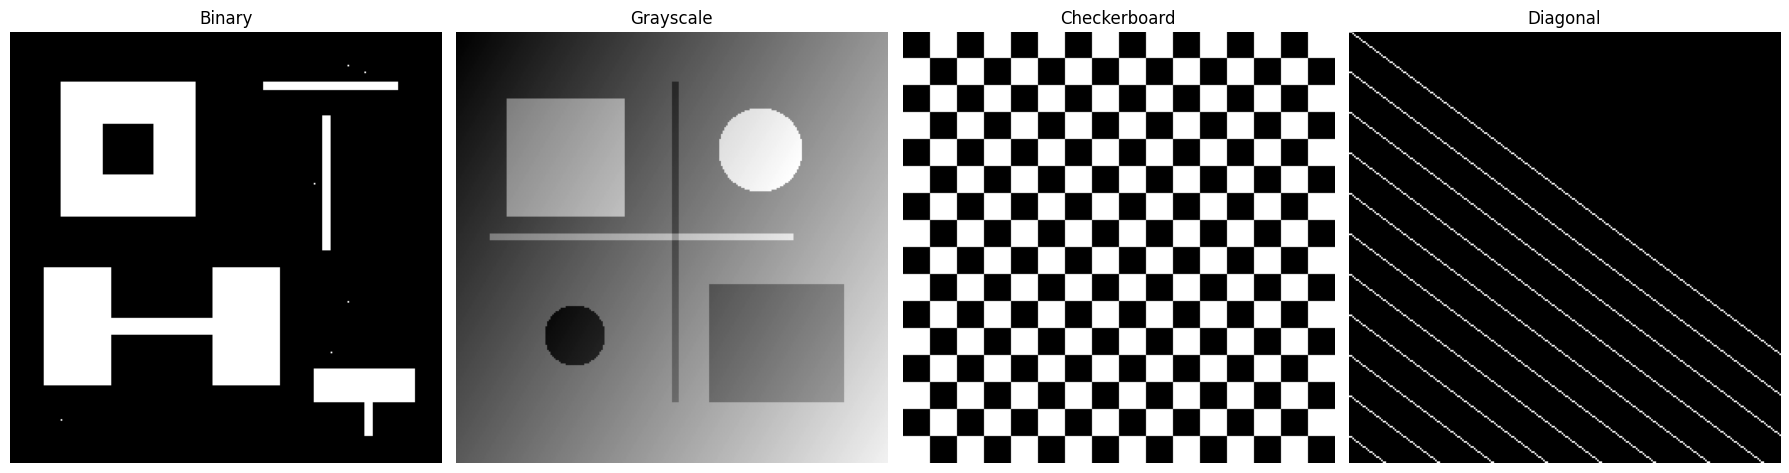

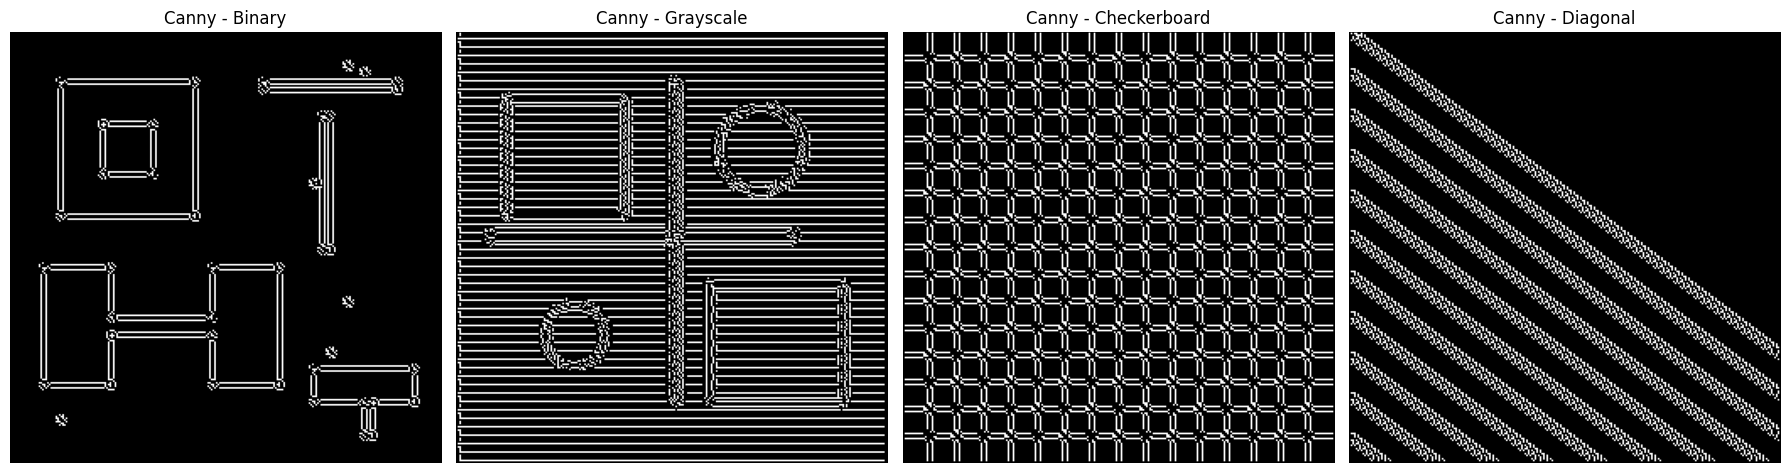

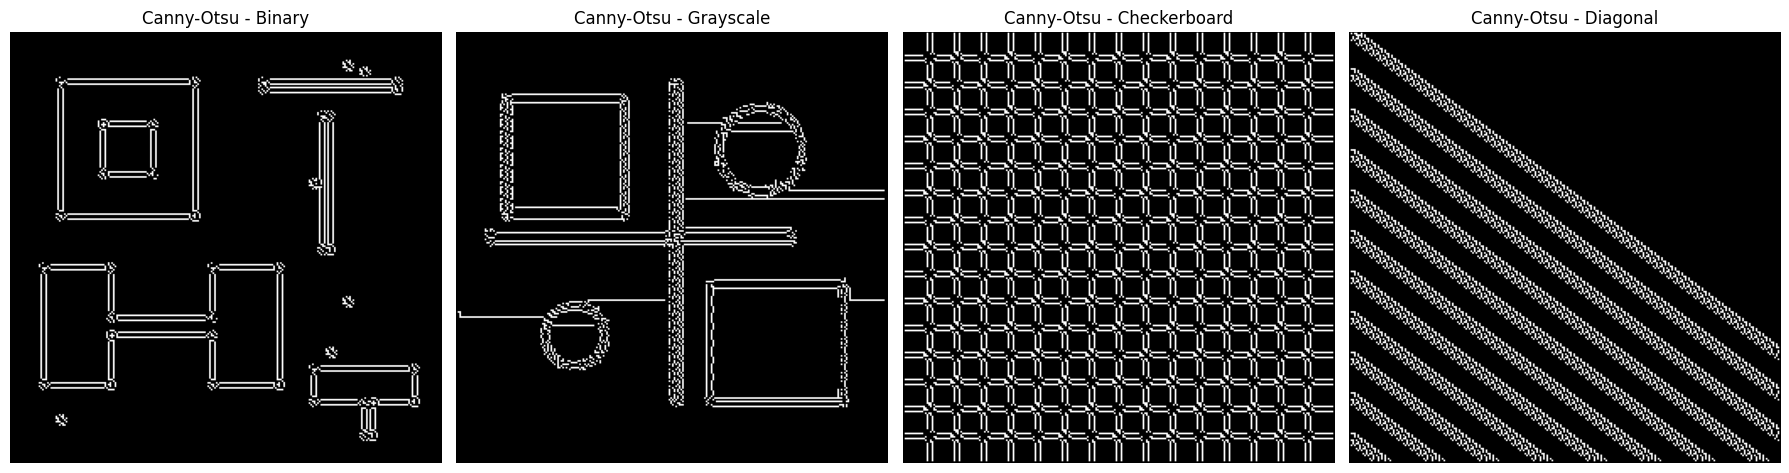

Ảnh gốc         | IoU Gốc (Manual)   | IoU Nới Lỏng (Cho phép lệch 1px)
Binary          |             2.71% |                        48.68%
Grayscale       |             3.04% |                         9.94%
Checkerboard    |             3.74% |                        52.64%
Diagonal        |            25.85% |                        61.11%


In [9]:
images = [
    binary_img,
    grayscale_img,
    checkerboard_img,
    diagonal_img
]

titles = [
    "Binary",
    "Grayscale",
    "Checkerboard",
    "Diagonal"
]
show_images(
    images,
    titles=titles,
    cols=4,
    figsize=(18,5)
)
results1 = []
results = []
for img in images:
    edges = canny_edge_detection(
        img,
        sigma=1.0,
        low_ratio=0.05,
        high_ratio=0.15,
        use_otsu=False
    )
    results.append(edges)

show_images(
    results,
    titles=[f"Canny - {t}" for t in titles],
    cols=4,
    figsize=(18,5)
)

for img in images:
    edges = canny_edge_detection(
        img,
        sigma=1.0,
        low_ratio=0.05,
        high_ratio=0.15,
        use_otsu=True
    )
    results1.append(edges)

show_images(
    results1,
    titles=[f"Canny-Otsu - {t}" for t in titles],
    cols=4,
    figsize=(18,5)
)
def calculate_iou(img1, img2):
    """Tính toán chỉ số IoU giữa 2 ảnh biên nhị phân."""
    bin1 = img1 > 0
    bin2 = img2 > 0
    intersection = np.logical_and(bin1, bin2).sum()
    union = np.logical_or(bin1, bin2).sum()
    return intersection / union if union != 0 else 1.0

# Tạo một ô code mới để tính toán lại IoU một cách chuẩn xác
if not HAS_CV2 or cv2 is None:
    print("[-] Thư viện OpenCV chưa được cài đặt.")
else:
    print("="*85)
    print(f"{'Ảnh gốc':<15} | {'IoU Gốc (Manual)':<18} | {'IoU Nới Lỏng (Cho phép lệch 1px)':<30}")
    print("="*85)

    # Khởi tạo kernel để giãn nở biên (bù trừ sai số lệch vị trí 1 pixel)
    kernel = np.ones((3, 3), np.uint8)

    for idx, img in enumerate(images):
        img_uint8 = img.astype(np.uint8) if img.dtype != np.uint8 else img
        
        # 1. Đồng bộ hóa bước làm mịn: Sử dụng chính ảnh đã qua xử lý hoặc ép OpenCV chạy trên ảnh mịn
        # Để công bằng nhất, ta giả định OpenCV nhận đầu vào đã được làm mịn đồng nhất
        high_thresh = img_uint8.max() * 0.15
        low_thresh = img_uint8.max() * 0.05
        cv2_edges = cv2.Canny(img_uint8, threshold1=low_thresh, threshold2=high_thresh)
        
        # Kết quả tự cài đặt của bạn
        custom_edges = results[idx]
        
        # 2. Tính IoU gốc (kết quả cũ của bạn)
        iou_strict = calculate_iou(custom_edges, cv2_edges)
        
        # 3. Tính IoU nới lỏng (Relaxed IoU bằng Dilation)
        # Giãn rộng các đường biên ra 1 pixel để kiểm tra xem cấu trúc xương cạnh có trùng nhau không
        custom_dilated = cv2.dilate(custom_edges, kernel, iterations=1)
        cv2_dilated = cv2.dilate(cv2_edges, kernel, iterations=1)
        iou_relaxed = calculate_iou(custom_dilated, cv2_dilated)
        
        print(f"{titles[idx]:<15} | {iou_strict * 100:>16.2f}% | {iou_relaxed * 100:>28.2f}%")

    print("="*85)

### Khi nào Otsu TỐT HƠN và TỆ HƠN? Giải thích.
1. Otsu TỐT HƠN:

    Trường hợp: Ảnh có Histogram dạng hai đỉnh rõ rệt (Bimodal) (đối tượng và nền có độ sáng khác biệt hẳn nhau) và ánh sáng đồng đều.
    
    Giải thích: Otsu hoạt động dựa trên nguyên lý tối đa hóa phương sai giữa hai lớp. Khi ảnh có 2 đỉnh tách biệt, 
                thuật toán sẽ cắt chính xác vào thung lũng giữa 2 đỉnh, tự động tìm ra ngưỡng tối ưu mà không cần cấu hình lại khi đổi ảnh khác.
2. Otsu TỆ HƠN:
    
    Trường hợp:Ảnh có nhiễu nặng hoặc ánh sáng không đồng đều (bị bóng mờ, gradient sáng).Ảnh có tỉ lệ kích thước đối tượng quá lệch 
        (ví dụ: chi tiết cạnh rất nhỏ trên một nền quá rộng - Unimodal Histogram).
    
    Giải thích: Do Otsu tính toán dựa trên thống kê toàn cục (Global), khi nền quá rộng hoặc ánh sáng phân bố lỗi, phương sai của nền 
    sẽ lấn át hoàn toàn. Otsu lúc này sẽ chọn sai ngưỡng, dẫn đến việc Canny bị mất cạnh quan trọng hoặc bám đầy cạnh nhiễu. 
    Trong trường hợp này, chỉnh tay hoặc phân ngưỡng thích nghi cục bộ (Adaptive) sẽ tốt hơn.

### Trả lời: nếu kết quả có quá nhiều cạnh giả, bạn điều chỉnh tham số nào trước tiên và theo hướng nào? Giải thích dựa trên cơ chế thuật toán.

Nếu kết quả Canny có quá nhiều cạnh giả, tham số cần điều chỉnh trước tiên là tăng độ lệch chuẩn $\sigma$ (Sigma) của bộ lọc Gaussian , hoặc tăng cặp ngưỡng Hysteresis ($\tau_{low}, \tau_{high}$).  

1. Điều chỉnh bộ lọc Gaussian: Tăng $\sigma$ (Sigma)
    
Hướng điều chỉnh: Tăng $\sigma$ (ví dụ: từ $1.0$ lên $2.0$ hoặc cao hơn).  
    
Giải thích cơ chế: Nhiễu tần số cao trong ảnh là nguyên nhân chính tạo ra các giá trị gradient giả lan tràn. Khi tăng $\sigma$, ma trận lọc Gaussian sẽ mở rộng kích thước và làm mịn (blur) ảnh mạnh hơn. Cơ chế này triệt tiêu các biến động cường độ nhỏ cục bộ (nhiễu), khiến các vùng nhiễu không thể tạo ra mức gradient đủ lớn ở bước Sobel tiếp theo, từ đó loại bỏ cạnh giả ngay từ gốc pipeline.

2. Điều chỉnh ngưỡng Hysteresis: Tăng $\tau_{high}$ và $\tau_{low}$
    
Hướng điều chỉnh: Tăng giá trị của cả hai ngưỡng (hoặc tăng $\tau_{high}$ rồi tính lại $\tau_{low} = \tau_{high} / 2$ nếu dùng tỉ lệ của Otsu).  
    
Giải thích cơ chế: * Ngưỡng $\tau_{high}$ quyết định một pixel có chắc chắn là cạnh thật hay không (strong edge). Nếu $\tau_{high}$ quá thấp, các đỉnh nhiễu còn sót sau khi blur sẽ bị phân loại nhầm thành các điểm khởi tạo cạnh strong.  Khi tăng $\tau_{high}$, ta siết chặt điều kiện lọc, chỉ giữ lại những cạnh thực sự sắc nét. Đồng thời, việc tăng $\tau_{low}$ giúp cắt đứt các chuỗi cạnh yếu (weak edges) do nhiễu kết nối vào, ngăn chặn cơ chế lan truyền DFS/BFS tích lũy các đoạn cạnh giả.
